In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import torch.utils.data as data 
from torch.nn import TripletMarginLoss

import torch_geometric as thg 
import torch_geometric.nn as nn 

import os 
import cv2 
import h5py
import numpy as np 
from tqdm import tqdm 
import matplotlib.pyplot as plt 


In [2]:
PATH = "Dataset.hdf5"

In [3]:
files = h5py.File(PATH, "r")
xdataset = np.array(files["X_jets"])
m0  = np.array(files["m0"])
pt = np.array(files["pt"])
ydataset = np.array(files["y"])

In [4]:
def standard_scale(data):
    
    # Min-Max Scaling to [0, 1]
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    
    return scaled_data

In [5]:
xdataset[:, :, :, 0] = standard_scale(np.sqrt(np.sqrt(xdataset[:, :, :, 0])))
xdataset[:, :, :, 1] = standard_scale(xdataset[:, :, :, 1])
xdataset[:, :, :, 2] = standard_scale(xdataset[:, :, :, 2])


m0 = standard_scale(m0)
pt = standard_scale(pt)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..134.72449].


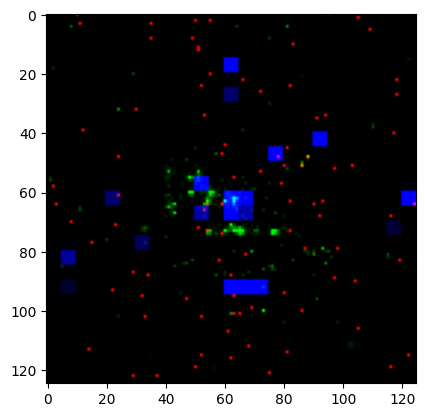

In [6]:
plt.imshow(xdataset[0] * 1000)

In [7]:
import numpy as np
import networkx as nx
import torch
from torch_geometric.data import Data
from scipy.spatial import KDTree, Delaunay
from tqdm import tqdm
import random


def extract_points_from_image(image, label, m0, pt):
    threshold = max(0.01, np.mean(image[image > 0]) * 0.1)  # Adaptive thresholding
    points = np.argwhere(image > threshold)
    intensities = image[points[:, 0], points[:, 1]]
    
    return np.column_stack((points, intensities, np.full(len(points), label), 
                            np.full(len(points), m0), np.full(len(points), pt))) if len(points) > 0 else np.empty((0, 6))

def compute_track_weights(track_img, all_nodes, G):
    track_points = np.argwhere(track_img > 0)
    if track_points.size == 0:
        return
    
    track_tree = KDTree(track_points)
    track_intensities = track_img[track_points[:, 0], track_points[:, 1]]
    
    for i, j in G.edges():
        center = (all_nodes[i, :2] + all_nodes[j, :2]) / 2.0
        distances, idxs = track_tree.query(center, k=len(track_points))
        weights = track_intensities[idxs] / (1 + (distances/60.0)**2)  # Inverse-square weighting
        G[i][j]['weight'] = max(np.sum(weights), 1e-6)

def point_cloud_to_graph(ecal_points, hcal_points, track_img):
    if len(ecal_points) == 0 and len(hcal_points) == 0:
        return nx.Graph()
    
    all_nodes = np.vstack([ecal_points, hcal_points]) if ecal_points.size and hcal_points.size else ecal_points if ecal_points.size else hcal_points
    all_nodes[:, 2] /= np.max(all_nodes[:, 2]) if np.max(all_nodes[:, 2]) > 0 else 1
    
    G = nx.Graph()
    node_attrs = {i: {'intensity': p[2], 'x': (p[0]/62.5) - 1, 'y': (p[1]/62.5) -  1, 
                  'is_ecal': (p[3] == -1), 'is_hcal': (p[3] == 1), 'm0': p[4], 'pt': p[5]} 
              for i, p in enumerate(all_nodes)}

    G.add_nodes_from(node_attrs.items())
    
    if len(all_nodes) > 2:
        delaunay = Delaunay(all_nodes[:, :2])
        for simplex in delaunay.simplices:
            for i, j in zip(simplex, np.roll(simplex, -1)):
                distance = np.linalg.norm(all_nodes[i, :2] - all_nodes[j, :2])
                weight = np.exp(-distance / 5)
                G.add_edge(i, j, weight=weight)
    
    compute_track_weights(track_img, all_nodes, G)
    
    return G

def convert_to_pyg_graph(graph):
    if len(graph) == 0:
        return None
    
    node_features = [[attrs['intensity'], attrs['x'], attrs['y'], attrs['is_ecal'], attrs['is_hcal'], attrs['m0'], attrs['pt']] for _, attrs in graph.nodes(data=True)]
    node_mapping = {node: i for i, node in enumerate(graph.nodes())}
    
    edge_index = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in graph.edges()], dtype=torch.long).t().contiguous()
    edge_weights = torch.tensor([graph[u][v]['weight'] for u, v in graph.edges()], dtype=torch.float)
    
    return Data(x=torch.tensor(node_features, dtype=torch.float), edge_index=edge_index, edge_attr=edge_weights)

def process_dataset_for_triplet(xdataset, ydataset, m0_values, pt_values):
    graph_list = {0: [], 1: []}  # Store graphs by label

    # First extract all graphs
    for idx, (xdata, ydata) in enumerate(tqdm(zip(xdataset, ydataset), desc="Processing images")):
        ecal_points = extract_points_from_image(xdata[:, :, 0], -1, m0_values[idx], pt_values[idx])
        hcal_points = extract_points_from_image(xdata[:, :, 1], 1, m0_values[idx], pt_values[idx])
        
        graph = point_cloud_to_graph(ecal_points, hcal_points, xdata[:, :, 2])
        if len(graph) == 0:
            continue
        
        pyg_graph = convert_to_pyg_graph(graph)
        if pyg_graph is None:
            continue
        
        pyg_graph.y = torch.tensor(ydata.astype(int), dtype=torch.long)
        graph_list[int(ydata)].append(pyg_graph)

    # Create triplets (Anchor, Positive, Negative)
    triplet_data = []
    for label in [0, 1]:
        other_label = 1 - label
        if len(graph_list[label]) < 2 or len(graph_list[other_label]) < 1:
            continue
        
        for anchor in graph_list[label]:
            positive = random.choice(graph_list[label])
            negative = random.choice(graph_list[other_label])
            triplet_data.append((anchor, positive, negative))

    return triplet_data


In [8]:
xyz = 10000
dataset = process_dataset_for_triplet(xdataset[:xyz], ydataset[:xyz], m0[:xyz], pt[:xyz])

Processing images: 10000it [01:56, 85.65it/s]


In [9]:
from sklearn.model_selection import train_test_split

# Assuming `graph_dataset` is your list of Data objects
train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train: {len(train_data)}, Validation: {len(val_data)}, Test: {len(test_data)}")


Train: 6000, Validation: 2000, Test: 2000


In [10]:
from torch_geometric.loader import DataLoader

batch_size = 32
from torch_geometric.data import Batch

def contrastive_collate_fn(batch):
    g1_list, g2_list, labels = zip(*batch)
    batch1 = Batch.from_data_list(g1_list)
    batch2 = Batch.from_data_list(g2_list)
    labels = torch.stack(labels)
    return batch1, batch2, labels

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=contrastive_collate_fn)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, collate_fn=contrastive_collate_fn)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=contrastive_collate_fn)


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GAT, GraphConv, SAGEConv,  SAGPooling, GraphNorm, global_mean_pool
from torch_geometric.nn.conv import GINEConv

class GNNBlock(nn.Module):
    def __init__(self, hidden_dim, input_dim=None):
        super(GNNBlock, self).__init__()
        input_dim = hidden_dim if input_dim is None else input_dim
        # GAT Layers
        self.gat1 = GAT(input_dim, hidden_dim * 2, num_layers=2)
        self.nor1 = GraphNorm(hidden_dim * 2)
        self.gat2 = GAT(hidden_dim * 2, hidden_dim * 2, num_layers=2)

        # GraphSAGE Layers
        self.sage1 = SAGEConv(input_dim, hidden_dim * 2)
        self.nor2 = GraphNorm(hidden_dim * 2)
        self.sage2 = SAGEConv(hidden_dim * 2, hidden_dim * 2)

        # GraphConv Layers
        self.graphconv1 = GraphConv(input_dim, hidden_dim * 2)
        self.nor3 = GraphNorm(hidden_dim * 2)
        self.graphconv2 = GraphConv(hidden_dim * 2, hidden_dim * 2)

        self.gine1 = GINEConv(nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim*2)), edge_dim=1)
        self.nor4 = GraphNorm(hidden_dim * 2)
        self.gine2 = GINEConv(nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim*2)), edge_dim=1)

        self.norm1 = GraphNorm(hidden_dim * 8 + input_dim)
        self.norm2 = GraphNorm(hidden_dim * 2)

        self.final = GAT(hidden_dim * 8 + input_dim, hidden_dim * 2, num_layers=2)
        self.residual = GraphConv(input_dim, hidden_dim * 2)

        # **Weighted Graph Pooling (SAGPooling)**
        self.pool1 = SAGPooling(hidden_dim * 2, ratio=0.25)  # Retains 25% of nodes

    def forward(self, x, edge_index, batch, edge_weight=None):
        dense = x
        residual = self.residual(x, edge_index, edge_weight)
        # GAT Branch
        gat_out = F.silu(self.nor1(self.gat1(x, edge_index, edge_weight)))
        gat_out = self.gat2(gat_out, edge_index, edge_weight)

        # GraphSAGE Branch
        sage_out = F.silu(self.nor2(self.sage1(x, edge_index)))
        sage_out = self.sage2(sage_out, edge_index)

        gine_out = F.silu(self.nor2(self.gine1(x, edge_index, edge_weight.reshape(-1, 1))))
        gine_out = self.gine2(gine_out, edge_index, edge_weight.reshape(-1, 1))

        # GraphConv Branch
        graphconv_out = F.silu(self.nor3(self.graphconv1(x, edge_index, edge_weight)))
        graphconv_out = self.graphconv2(graphconv_out, edge_index, edge_weight)

        # print(gine_out.shape, sage_out.shape, graphconv_out.shape, dense.shape, gat_out.shape)

        # **Concatenate multi-path features**
        x = F.silu(self.norm1(torch.cat([gat_out, sage_out, graphconv_out, gine_out, dense], dim=1)))

        x = F.silu(self.norm2(self.final(x, edge_index, edge_weight) + residual))
        
        # **Apply weighted pooling**
        x, edge_index, edge_weight, batch, _, _ = self.pool1(x, edge_index, edge_weight, batch)

        return x, edge_index, edge_weight, batch


class GNNModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=24, output_dim=256):
        super(GNNModel, self).__init__()
        self.graph1 = GNNBlock(hidden_dim, input_dim)
        self.graph2 = GNNBlock(hidden_dim * 2)
        self.graph3 = GNNBlock(hidden_dim * 4)
        


        self.mlp = nn.Linear(hidden_dim * 8, output_dim)
        self.final_fc = nn.Linear(output_dim, output_dim)

        self.drop = nn.Dropout(0.0)

    def forward(self, data):
        x, e, b = data.x, data.edge_index, data.batch
        edge_weight = data.edge_attr if hasattr(data, 'edge_attr') else None  # Get edge weights if available

        # Pass through GNN blocks
        x, e, edge_weight, b = self.graph1(x, e, b, edge_weight)
        x, e, edge_weight, b = self.graph2(x, e, b, edge_weight)
        x, e, edge_weight, b = self.graph3(x, e, b, edge_weight)


        x = global_mean_pool(x, b)

        # Fully connected layers
        x = F.silu(self.mlp(self.drop(x)))
        return self.final_fc(self.drop(x))

In [12]:
def l2_regularization(model, weight_decay=1e-6, bias_decay=1e-8):
    weight_decay_loss = 0
    bias_decay_loss = 0
    for name, param in model.named_parameters():
        if 'weight' in name:
            weight_decay_loss += torch.norm(param, p=2)  # L2 norm for weights
        elif 'bias' in name:
            bias_decay_loss += torch.norm(param, p=1)  # L2 norm for biases
    return weight_decay * weight_decay_loss + bias_decay * bias_decay_loss


In [13]:
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model, optimizer, scheduler, and loss
model = GNNModel(input_dim=7, hidden_dim=32, output_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
loss_fn = nn.TripletMarginLoss(margin=1.0)

# Custom collate function for triplet loss (Anchor, Positive, Negative)
def triplet_collate_fn(batch):
    anchors, positives, negatives = zip(*batch)
    anchor_batch = Batch.from_data_list(anchors)
    positive_batch = Batch.from_data_list(positives)
    negative_batch = Batch.from_data_list(negatives)
    return anchor_batch, positive_batch, negative_batch

# Compute accuracy based on triplet distances
def compute_accuracy(anchor, positive, negative):
    pos_dist = torch.norm(anchor - positive, dim=1)
    neg_dist = torch.norm(anchor - negative, dim=1)
    correct = (pos_dist < neg_dist).sum().item()
    return correct, len(anchor)

# Training loop
def train():
    model.train()
    for epoch in range(100):
        total_loss = 0
        total_correct = 0
        total_samples = 0
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for anchor, positive, negative in train_loader_tqdm:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
            optimizer.zero_grad()

            anchor_out = model(anchor)
            positive_out = model(positive)
            negative_out = model(negative)

            loss = loss_fn(anchor_out, positive_out, negative_out)
            loss += l2_regularization(model)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct, samples = compute_accuracy(anchor_out, positive_out, negative_out)
            total_correct += correct
            total_samples += samples

            train_loader_tqdm.set_postfix(loss=total_loss / (len(train_loader_tqdm) + 1e-6), acc=total_correct / (total_samples + 1e-6))

        val_loss, val_acc = validate()
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}, Train Loss: {total_loss / len(train_loader):.4f}, Train Acc: {total_correct / total_samples:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

# Validation loop
def validate():
    model.eval()
    val_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc="Validation")
        for anchor, positive, negative in val_loader_tqdm:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            anchor_out = model(anchor)
            positive_out = model(positive)
            negative_out = model(negative)

            loss = loss_fn(anchor_out, positive_out, negative_out)
            val_loss += loss.item()
            correct, samples = compute_accuracy(anchor_out, positive_out, negative_out)
            total_correct += correct
            total_samples += samples

        avg_loss = val_loss / len(val_loader)
        avg_acc = total_correct / total_samples
        print(f"Validation Loss: {avg_loss:.4f}, Validation Accuracy: {avg_acc:.4f}")
        return avg_loss, avg_acc

train()


/Users/macbook/Desktop/अनुसन्धानम् च विकासः/GSOC2025_GENIE/graph/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Validation: 100%|██████████| 63/63 [00:07<00:00,  8.62it/s]


Validation Loss: 1.0121, Validation Accuracy: 0.5020
Epoch 1, Train Loss: 1.0529, Train Acc: 0.5018, LR: 0.000100


Validation: 100%|██████████| 63/63 [00:07<00:00,  8.64it/s]


Validation Loss: 1.0270, Validation Accuracy: 0.4875
Epoch 2, Train Loss: 0.9980, Train Acc: 0.5170, LR: 0.000100


Validation: 100%|██████████| 63/63 [00:07<00:00,  8.58it/s]


...

Validation Loss: 0.9065, Validation Accuracy: 0.5840
Epoch 59, Train Loss: 0.5914, Train Acc: 0.7532, LR: 0.000000


Validation: 100%|██████████| 63/63 [00:07<00:00,  7.99it/s]


Validation Loss: 0.9069, Validation Accuracy: 0.5840
Epoch 60, Train Loss: 0.5879, Train Acc: 0.7497, LR: 0.000000


Epoch 61:  49%|████▉     | 92/188 [00:22<00:23,  4.10it/s, acc=0.743, loss=0.306] 


KeyboardInterrupt: 